In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aryansharma8911/open-closed-eyes-and-yawning-labelled")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/aryansharma8911/open-closed-eyes-and-yawning-labelled/versions/1


In [ ]:
import os

os.listdir(path)


['merged_dataset', 'eyesyawn.pt', 'run.py']

In [ ]:
dataset_base = os.path.join(path, "merged_dataset")
os.listdir(dataset_base)


['dataset.yaml', 'train', 'test', 'val']

In [ ]:
import yaml

with open(os.path.join(dataset_base, "dataset.yaml")) as f:
    data = yaml.safe_load(f)

print("YOLO class mapping:")
print(data["names"])


YOLO class mapping:
['closed_eye', 'open_eye', 'yawning']


In [ ]:
YOLO_TO_PROJECT = {
    0: "alert",     # open_eye
    1: "drowsy",    # closed_eye
    2: "yawning"    # yawn
}


In [ ]:
OUTPUT_BASE = "/content/driver_drowsiness/train"

classes = ["alert", "drowsy", "yawning"]

for cls in classes:
    os.makedirs(os.path.join(OUTPUT_BASE, cls), exist_ok=True)

print("✅ Output folders created")


✅ Output folders created


In [ ]:
import cv2

IMG_SIZE = (224, 224)

def preprocess_and_save(img_path, save_path):
    img = cv2.imread(img_path)
    if img is None:
        return

    img = cv2.resize(img, IMG_SIZE)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    cv2.imwrite(save_path, img)


In [ ]:
import cv2

IMG_SIZE = (224, 224)

def preprocess_and_save(img_path, save_path):
    img = cv2.imread(img_path)
    if img is None:
        return

    img = cv2.resize(img, IMG_SIZE)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    cv2.imwrite(save_path, img)


In [ ]:
YOLO_IMG_DIR = os.path.join(dataset_base, "train/images")
YOLO_LBL_DIR = os.path.join(dataset_base, "train/labels")

converted = 0

for label_file in os.listdir(YOLO_LBL_DIR):
    label_path = os.path.join(YOLO_LBL_DIR, label_file)

    with open(label_path, "r") as f:
        line = f.readline().strip()
        if not line:
            continue

        class_id = int(line.split()[0])

    project_class = YOLO_TO_PROJECT[class_id]

    img_name = label_file.replace(".txt", ".jpg")
    img_path = os.path.join(YOLO_IMG_DIR, img_name)

    if not os.path.exists(img_path):
        continue

    save_path = os.path.join(OUTPUT_BASE, project_class, img_name)
    preprocess_and_save(img_path, save_path)
    converted += 1

print(f"✅ Converted {converted} images to CNN format")


✅ Converted 33365 images to CNN format


In [ ]:
for cls in classes:
    count = len(os.listdir(os.path.join(OUTPUT_BASE, cls)))
    print(f"{cls.upper()} → {count} images")


ALERT → 14589 images
DROWSY → 10639 images
YAWNING → 8137 images


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

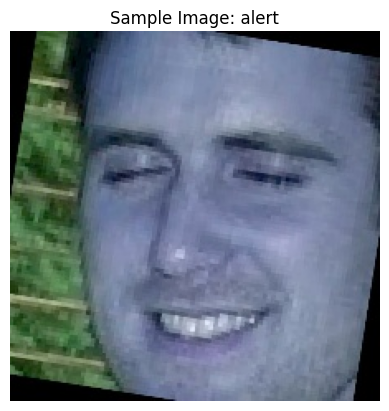

In [ ]:
import matplotlib.pyplot as plt
import random

cls = "alert"
img_name = random.choice(os.listdir(os.path.join(OUTPUT_BASE, cls)))

img = cv2.imread(os.path.join(OUTPUT_BASE, cls, img_name))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title(f"Sample Image: {cls}")
plt.axis("off")


In [ ]:
import os

DATA_DIR = "/content/driver_drowsiness/train"
classes = ["alert", "drowsy", "yawning"]

print("Dataset path:", DATA_DIR)


Dataset path: /content/driver_drowsiness/train


In [ ]:
import cv2

corrupt_images = []

for cls in classes:
    cls_path = os.path.join(DATA_DIR, cls)
    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        img = cv2.imread(img_path)
        if img is None:
            corrupt_images.append(img_path)

print(f"❌ Corrupt images found: {len(corrupt_images)}")


❌ Corrupt images found: 0


In [ ]:
invalid_size = []

EXPECTED_SIZE = (224, 224)

for cls in classes:
    cls_path = os.path.join(DATA_DIR, cls)
    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        img = cv2.imread(img_path)
        if img is None:
            continue
        h, w, _ = img.shape
        if (w, h) != EXPECTED_SIZE:
            invalid_size.append(img_path)

print(f"⚠ Images with invalid size: {len(invalid_size)}")


⚠ Images with invalid size: 0


In [ ]:
DATA_DIR = "/content/driver_drowsiness/train"


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import os


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    brightness_range=(0.8, 1.2),
    validation_split=0.2
)


In [ ]:
train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="training",
    shuffle=True
)


Found 26694 images belonging to 3 classes.


In [ ]:
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

val_generator = val_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)


Found 6671 images belonging to 3 classes.


In [ ]:
train_generator.class_indices


{'alert': 0, 'drowsy': 1, 'yawning': 2}

In [ ]:
# ---------------- MANUAL CLASS WEIGHTS ----------------
# Based on confusion matrix analysis to improve drowsy detection

import numpy as np

class_weights = {
    0: 1.0,   # alert
    1: 1.4,   # drowsy (increased importance - safety critical)
    2: 1.2    # yawning
}

print("Updated Class Weights:")
print(class_weights)


Updated Class Weights:
{0: 1.0, 1: 1.4, 2: 1.2}


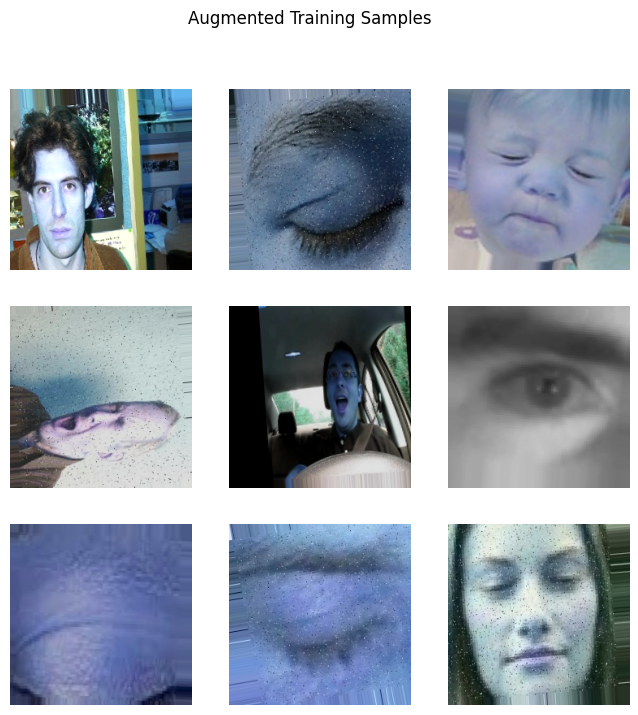

In [ ]:
import matplotlib.pyplot as plt

x_batch, y_batch = next(train_generator)

plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(x_batch[i])
    plt.axis("off")
plt.suptitle("Augmented Training Samples")
plt.show()


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model


In [ ]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False  # IMPORTANT: freeze base CNN

print("Base model frozen:", not base_model.trainable)


Base model frozen: True


In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation="relu")(x)
x = Dropout(0.4)(x)

x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)

output = Dense(3, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),  # reduced LR
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,619,203 (9.99 MB)

 Trainable params: 361,219 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-6
    ),
    ModelCheckpoint(
        "best_stage1_model.h5",
        monitor="val_loss",
        save_best_only=True
    )
]


In [ ]:
len(train_generator.classes)
len(val_generator.classes)

6671

In [ ]:
len(val_generator.classes)

6671

In [ ]:
history_stage1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=callbacks,
    class_weight=class_weights
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


In [ ]:
# ---------------- STAGE 2 FINE TUNING ----------------

base_model.trainable = True

# Freeze all except last 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

history_stage2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=callbacks,
    class_weight=class_weights
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks_finetune = [
    EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6
    ),
    ModelCheckpoint(
        "best_finetuned_model.keras",
        monitor="val_loss",
        save_best_only=True
    )
]


In [ ]:
import numpy as np

# Get true labels
y_true = val_generator.classes

# Predict probabilities
y_pred_probs = model.predict(val_generator)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_probs, axis=1)

print("Prediction completed")


In [ ]:
class_names = list(val_generator.class_indices.keys())
class_names


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)


In [ ]:
from sklearn.metrics import recall_score

drowsy_index = class_names.index("drowsy")

drowsy_recall = recall_score(
    y_true,
    y_pred,
    labels=[drowsy_index],
    average=None
)

print("Drowsy Recall:", drowsy_recall[0])


In [ ]:
model.save("driver_drowsiness_cnn.h5")
print("✅ Model saved as driver_drowsiness_cnn.h5")


In [ ]:
from google.colab import files
files.download("driver_drowsiness_cnn.h5")


In [ ]:
class_order = val_generator.class_indices
class_order

